<a href="https://colab.research.google.com/github/Harshini2007-31/AIML-collab/blob/main/logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [2]:
df = pd.read_csv('carprices.csv')

In [3]:
print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   Mileage  Age(yrs)  Sell Price($)
0    69000         6          18000
1    35000         3          34000
2    57000         5          26100
3    22500         2          40000
4    46000         4          31500


In [4]:
print("\nDataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Mileage        20 non-null     int64
 1   Age(yrs)       20 non-null     int64
 2   Sell Price($)  20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes
None

Missing values:
Mileage          0
Age(yrs)         0
Sell Price($)    0
dtype: int64


In [5]:
X = df[['Mileage', 'Age(yrs)']]
y = df['Sell Price($)']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)

In [9]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Performance:")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)



Model Performance:
R2 Score: 0.8360253892678229
MAE: 2967.9153475578505
MSE: 10120000.553731432
RMSE: 3181.1948311493643


In [10]:
print("\nModel Coefficients:")
print("Intercept:", model.intercept_)
print("Mileage coefficient:", model.coef_[0])
print("Age(yrs) coefficient:", model.coef_[1])




Model Coefficients:
Intercept: 48443.15478494282
Mileage coefficient: -0.352546397595829
Age(yrs) coefficient: -309.16190979572895


In [11]:
new_data = pd.DataFrame({
    'Mileage': [45000],
    'Age(yrs)': [4]
})

predicted_price = model.predict(new_data)
print("\nPredicted price for Mileage=45000 and Age=4:")
print(predicted_price[0])



Predicted price for Mileage=45000 and Age=4:
31341.919253947595


In [12]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted:")
print(results)


Actual vs Predicted:
   Actual Price  Predicted Price
0         18000     22262.481892
1         19700     22571.643802
2         35000     38560.990557
3         34000     35176.545140


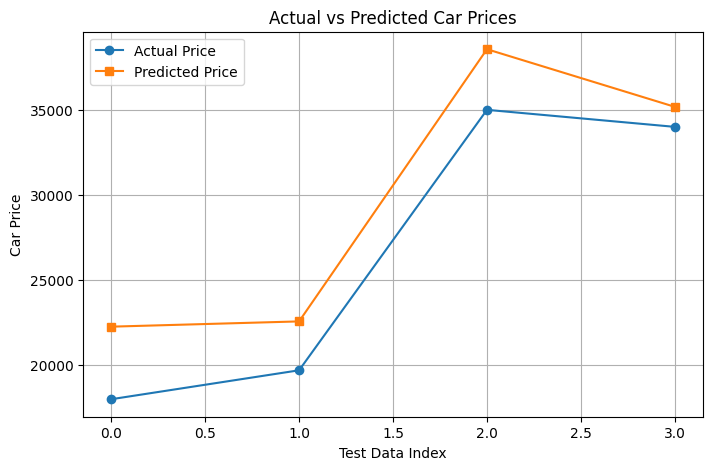

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(len(y_test)), y_test.values, marker='o', label='Actual Price')
plt.plot(range(len(y_pred)), y_pred, marker='s', label='Predicted Price')
plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Test Data Index")
plt.ylabel("Car Price")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
model_full = LinearRegression()
model_full.fit(X, y)
full_pred = model_full.predict(X)
full_r2 = r2_score(y, full_pred)

print("\nR2 Score on Full Dataset:", full_r2)


R2 Score on Full Dataset: 0.9358277461816623
